In [1]:
import sys
import sire
from os.path import abspath
import os
print(abspath(os.getcwd()) + "/sire_ball_free_fall3.xml")
sim = sire.Simulator()
sire.fromXmlFile(sim, abspath(os.getcwd()) + "/sire_ball_free_fall3.xml")
sim.init()

d:\code\sire\demo\demo_python\sire\ballFreefall/sire_ball_free_fall3.xml


In [2]:
m = sim.model()
pe = sim.physicsEngine()
sl = sim.simulationLoop()

ball = m.partPool()[1]  # ball is part 1

print(f"Ball init: z={ball.pq[2]:.4f}  vz={ball.vs[2]:.3f}")
print()
print(f"{'t(s)':>8s}  {'ball_z':>8s}  {'vz':>8s}  {'penet_pair':>12s}  contacts")

def penetration_z(contact_results):
    """Extract max penetration z from contact pair results."""
    pen = 0.0
    for c in contact_results:
        if (c[0] == 0 and c[1] == 1) or (c[1] == 0 and c[0] == 1):
            # pair format: pa, pb, fx, fy, fz, px, py, pz (7 elements from Sire)
            if len(c) >= 7:
                pen = c[6]  # pz = penetration z
    return pen
i = 0
for i in range(50000):  # max 6 seconds
    try:
        sl.handleContact()
    except RuntimeError as e:
        print(f"  CRASH at t={sl.simTime():.3f}s: {e}")
        break

    t = sl.simTime()
    bz = ball.pq[2]
    bvz = ball.vs[2]
    cr = sl.lastContactPairResults()
    pz = penetration_z(cr)
    gc = sum(1 for c in cr if (c[0] == 0 and c[1] == 1) or (c[1] == 0 and c[0] == 1))

    if i % 5 == 0:  # every 0.1s
        print(f"{t:8.3f}  {bz:8.4f}  {bvz:8.3f}  {pz:12.6f}  {gc:5d}")

    # Stop if ball fell through and stopped
    if bz < -5.0:
        print(f"  Ball fell through terrain at t={t:.3f}s")
        break
    if t > 10:
        break

print(f"\nFinal: t={sl.simTime():.3f}s  ball_z={ball.pq[2]:.4f}")

# MeshCat
sl.recordsContactCptInfo()
display_init = sim.displayInitJson()
result = sl.recordsToJson()
n_frames = len(result.get('timeIndex', []))
if n_frames > 0:
    import meshcat
    vis = meshcat.Visualizer()
    # resource_path = os.path.join(os.path.dirname(os.path.dirname(_HERE)), 'dogRL')
    resourcePath = "D:/code/sire/web_interface/public"
    sire.robotInit(m.numLinks(), resourcePath, display_init, vis)
    sire.animateRobotByRecords(m.numLinks(), result, 1000, vis)
    vis.jupyter_cell()

Ball init: z=1.5000  vz=0.000

    t(s)    ball_z        vz    penet_pair  contacts
   0.001    1.5000    -0.010      0.000000      0
   0.006    1.4998    -0.059      0.000000      0
   0.011    1.4994    -0.108      0.000000      0
   0.016    1.4987    -0.157      0.000000      0
   0.021    1.4977    -0.206      0.000000      0
   0.026    1.4966    -0.255      0.000000      0
   0.031    1.4951    -0.304      0.000000      0
   0.036    1.4935    -0.353      0.000000      0
   0.041    1.4916    -0.402      0.000000      0
   0.046    1.4894    -0.451      0.000000      0
   0.051    1.4870    -0.500      0.000000      0
   0.056    1.4843    -0.549      0.000000      0
   0.061    1.4814    -0.598      0.000000      0
   0.066    1.4783    -0.647      0.000000      0
   0.071    1.4749    -0.697      0.000000      0
   0.076    1.4713    -0.746      0.000000      0
   0.081    1.4674    -0.795      0.000000      0
   0.086    1.4633    -0.844      0.000000      0
   0.091    1.45

In [3]:
model = sim.model()
displayInitJson = sim.displayInitJson()

lowerBound: 452 upperBound: 500
452 0.45200000000000035 0.0010000000000000009 [0.0, 0.0, 0.4956718199999999, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -4.434119999999978, 0.0, 0.0, 0.0] [0.0, 0.0, 4459.414804122685, 0.0, 0.0, 0.0] None
453 0.45300000000000035 0.0010000000000000009 [0.0, 0.0, 0.4956971148041226, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.025294804122711234, 0.0, 0.0, 0.0] [0.0, 0.0, -9.81, 0.0, 0.0, 0.0] None
454 0.45400000000000035 0.0010000000000000009 [0.0, 0.0, 0.4957125996082453, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.015484804122711224, 0.0, 0.0, 0.0] [0.0, 0.0, -9.81, 0.0, 0.0, 0.0] None
455 0.45500000000000035 0.0010000000000000009 [0.0, 0.0, 0.49571827441236804, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.005674804122711215, 0.0, 0.0, 0.0] [0.0, 0.0, -5.462732920672574, 0.0, 0.0, 0.0] None
456 0.45600000000000035 0.0010000000000000009 [0.0, 0.0, 0.4957184864835701, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.00021207120203863613, 0.0, 0.0, 0.0] [0.0, 0.0, 0.03086184765542832, 0.0, 0.0, 0.0] None
457 0.4570000

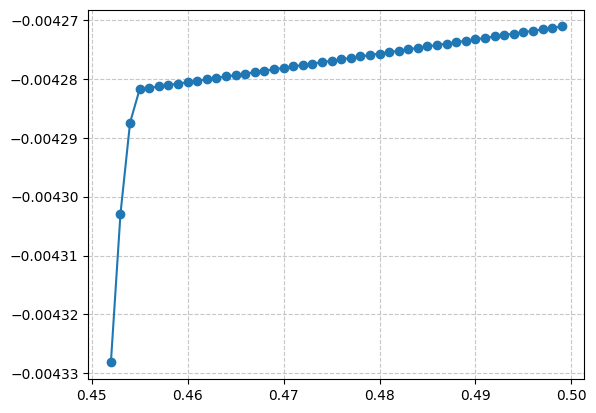

In [15]:
import matplotlib.pyplot as plt
import numpy as np
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0.452)
upperBound = sire.binarySearch(timeIndices, 0.5)
print("lowerBound:", lowerBound, "upperBound:", upperBound)
for i in range(lowerBound, upperBound):
  print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  y.append(sire.pq2tfmatrix(partpq[i][1])[2, 3]-0.5)  # z position from transformation matrix
  # print(y[-1])
  yv.append(partvs[i][1][2])  # z velocity
plt.plot(x, y, marker='o', label='height (m)')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data-1.pdf", format="pdf")
plt.show()

In [ ]:
for i in range(800):
  currentIdx = 4000 + i
  print(result["timeIndex"][currentIdx])

3.9999999999996705
4.000999999999671
4.001999999999671
4.0029999999996715
4.003999999999672
4.004999999999672
4.0059999999996725
4.006999999999673
4.007999999999673
4.0089999999996735
4.009999999999674
4.010999999999674
4.0119999999996745
4.012999999999675
4.013999999999675
4.0149999999996755
4.015999999999676
4.016999999999676
4.0179999999996765
4.018999999999677
4.019999999999677
4.0209999999996775
4.021999999999678
4.022999999999678
4.0239999999996785
4.024999999999679
4.025999999999679
4.0269999999996795
4.02799999999968
4.02899999999968
4.0299999999996805
4.030999999999681
4.031999999999681
4.0329999999996815
4.033999999999682
4.034999999999682
4.0359999999996825
4.036999999999683
4.037999999999683
4.0389999999996835
4.039999999999684
4.040999999999684
4.0419999999996845
4.042999999999685
4.043999999999685
4.0449999999996855
4.045999999999686
4.046999999999686
4.0479999999996865
4.048999999999687
4.049999999999687
4.0509999999996875
4.051999999999688
4.052999999999688
4.0539999999

904 0.9040000000000007 0.0010000000000000009 [0.0, 0.0, 0.9912119999999855, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.85920000000009, 0.0, 0.0, 0.0] [0.0, 0.0, 8883.665916339065, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 8893.465916339064], 'contactWrench': [-0.0, 0.0, 8893.465916339064, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4956059999999928, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
905 0.9050000000000007 0.001 [0.0, 0.0, 0.9912364659163245, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.024465916338975546, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49561823295816226, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -2.446591633897821e-05, 'geomIdA': 0, 'geomIdB': 1}, 'separation_spe

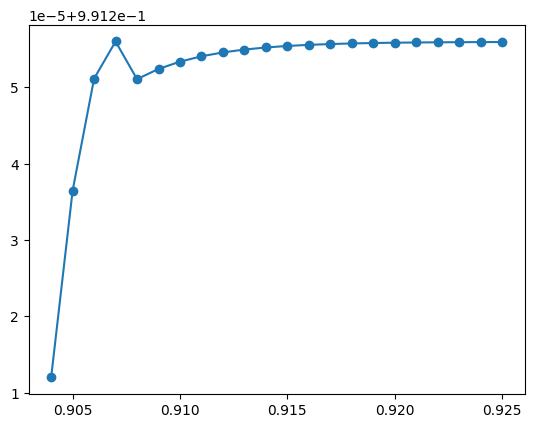

In [ ]:
import matplotlib.pyplot as plt
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []

lowerBound = binarySearch(timeIndices, 0.903)
upperBound = binarySearch(timeIndices, 0.925)

for i in range(lowerBound, upperBound + 1):
  print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  y.append(pq2tfmatrix(partpq[i][1])[2, 3])  # z position from transformation matrix

plt.plot(x, y, marker='o', linestyle='-')

In [ ]:
currentIdx = 4015
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.0052)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.00525)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])


4015 4.0149999999996755 0.001 [0.0, 0.0, 0.9912559487490024, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 4.5486977508668094e-14, 0.0, 0.0, 0.0] [0.0, 0.0, -1.7763568394002505e-15, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 9.799999999999999], 'contactWrench': [-0.0, 0.0, 9.799999999999999, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4956279743745012, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 4.900000016849759e-08, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
4006 4.0059999999996725 0.001 [0.0, 0.0, 0.9912559487490024, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 4.548520115182869e-14, 0.0, 0.0, 0.0] [0.0, 0.0, 1.7763568394002505e-15, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 9.800000000000002], 'contactWrench': [-0.0, 0.0, 9.800000000000002, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4956279743745012, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 4.90000

In [ ]:
# 4.190999999999734 [0.0, 0.0, 1.0000021810337338, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.002929150576415091, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
# 4.191999999999735 [0.0, 0.0, 0.9999894518831575, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.012729150576418364, 0.0, 0.0, 0.0] [0.0, 0.0, 87.49722059997538, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 97.29722059997538], 'contactWrench': [-0.0, 0.0, 97.29722059997538, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999472594157873, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.192999999999735 [0.0, 0.0, 0.9999914954560379, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.00028451290447994385, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999574772801897, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -2.1780204040311446e-07, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.193999999999735 [0.0, 0.0, 0.9999819799689424, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.009515487095523328, 0.0, 0.0, 0.0] [0.0, 0.0, 895.3468337893621, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 905.1468337893621], 'contactWrench': [-0.0, 0.0, 905.1468337893621, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4999909899844712, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 9.515487095490549e-06, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
